In [60]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [61]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Ocean Basins

In [34]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(time = slice('1979', '2023'))

ocean_mask = ~sst.isel(time = 1).sst.isnull()

In [35]:
sst = sst.where(sst.time.dt.month.isin([8,9,10]), drop=True).groupby('time.year').mean()

In [36]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

na_mask = masks.open_ocean.isin(1).where(masks.lat>=0)
sa_mask = masks.open_ocean.isin(1).where(masks.lat<0)
pacific_mask = masks.open_ocean.isin([2,3])
atlantic_mask = masks.open_ocean.isin([1])
southern_mask = masks.open_ocean.isin([5])

ocean_mask = masks.seamask.isin([1])

In [37]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', None))

In [38]:
#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')


In [39]:
#only where ocean 
t2m = t2m.where(masks.seamask ==1)

In [40]:
weights = np.cos(np.deg2rad(t2m.lat))


ocean_surface = ocean_mask.weighted(weights).sum()

In [41]:
#compute anom
clim = t2m.sel(time = slice('1991', '2020')).t2m.groupby('time.month').mean()
t2m['anom'] = t2m.t2m.groupby('time.month') -clim



# Assuming your dataset is named `ds`
# Shift the year label to start from April
ds_shifted = t2m.assign_coords(year=((t2m.time.dt.year - (t2m.time.dt.month < 4))))

# Group by the new "year" and compute the mean
ds_yearly = ds_shifted.groupby("year").mean()

# Print result
print(ds_yearly)


In [14]:
t2m = ds_yearly.sel(year = slice('1979', None))

#take aso season only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10]), drop=True).groupby('time.year').mean()

In [42]:
#take full year
t2m = t2m.groupby('time.year').mean()

In [43]:
npol = t2m.where(masks.open_ocean == 4).weighted(weights).mean(['lat', 'lon'])
npol = npol * (masks.open_ocean == 4).weighted(weights).sum()/ocean_surface

In [44]:
natl = t2m.sel(lat = slice(90, 0)).where(masks.open_ocean ==1).weighted(weights).mean(['lat', 'lon'])
natl = natl * (masks.sel(lat = slice(0,90)).open_ocean ==1).weighted(weights).sum()/ocean_surface

In [45]:
satl = t2m.sel(lat = slice(0, -90)).where(masks.open_ocean ==1).weighted(weights).mean(['lat', 'lon'])
satl = satl * (masks.sel(lat = slice(-90,0)).open_ocean ==1).weighted(weights).sum()/ocean_surface

In [46]:
pac = t2m.where(masks.open_ocean.isin([2])).weighted(weights).mean(['lat', 'lon'])
pac = pac * (masks.open_ocean.isin([2])).weighted(weights).sum()/ocean_surface

In [47]:
ind = t2m.where(masks.open_ocean.isin([3])).weighted(weights).mean(['lat', 'lon'])
ind = ind * (masks.open_ocean.isin([3])).weighted(weights).sum()/ocean_surface

In [48]:
sou = t2m.where(masks.open_ocean==5).weighted(weights).mean(['lat', 'lon'])
sou = sou * (masks.open_ocean==5).weighted(weights).sum()/ocean_surface

In [49]:
ls = [ind, pac, sou, satl, natl, npol]

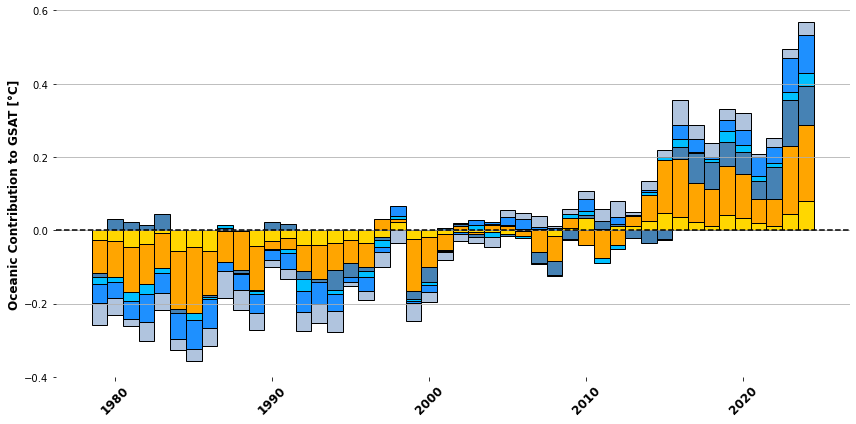

In [50]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))

labels = ['Pacific', 'Indian Ocean','Southern Ocean', 'South Atlantic', 'North Atlantic', 'Arctic']

colors = ['gold', 'orange', 'steelblue', 'deepskyblue', 'dodgerblue', 'lightsteelblue']


bottom_pos = np.zeros(len(npol['year']))
bottom_neg = np.zeros(len(npol['year']))

for i, r in enumerate(ls):
    values = r['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
#ax.legend()
#ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'bold', size = 12)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution to GSAT [°C]', fontsize = 12)




ax.set_ylim(-0.4,.6)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    

#ax.legend()

In [51]:
a = xr.zeros_like(masks.open_ocean)

In [52]:


#replace this by 
na_mask = masks.open_ocean.isin(1).where(masks.lat>=0)
sa_mask = masks.open_ocean.isin(1).where(masks.lat<0)
pacific_mask = masks.open_ocean.isin([2,3])
atlantic_mask = masks.open_ocean.isin([1])
southern_mask = masks.open_ocean.isin([5])


In [53]:
a = -masks.open_ocean

#southern o
a = xr.where(a ==-5, 1,a)
#arct
a = xr.where(a ==-4, 5, a)

#natl
a =xr.where((a == -1) & (a.lat>=0), 4,a)

#satl
a =xr.where((a == -1) & (a.lat<0), 3,a)


#indopac
a = xr.where(a.isin([-2,-3]), 2, a)


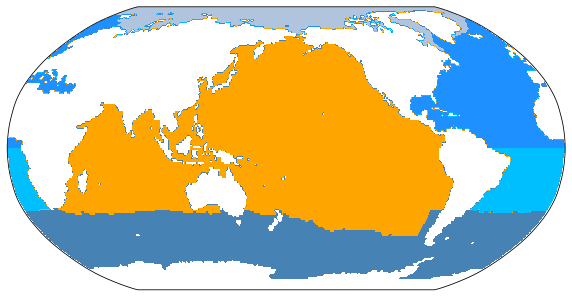

In [54]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl


# Define colors for different regions

#land, south, indopac, south atl, north atl, artc.
colors = ['white','steelblue', 'orange', 'deepskyblue', 'dodgerblue' ,'lightsteelblue']

#alternatie colorbar
#colors = ['white','#A6C7F3','#172DBB',  '#1DAA24',  '#0D5F11', '#DEE5EE']

cmap = (mpl.colors.ListedColormap(colors)
       )
# Define projection (Robinson projection)
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 6))

# Plot data
im = ax.imshow(a, extent=[0, 360, -90, 90], transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=len(colors)-1)

# Add coastlines
#ax.coastlines()

"""# Add colorbar
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(colors)), orientation='vertical', shrink=0.5)
cbar.ax.set_yticklabels(labels[::-1])
"""
# Add title
#plt.title('Oceanic Regions')
plt.gca().invert_yaxis()
plt.show()

In [56]:
a = xr.zeros_like(masks.open_ocean)

In [57]:

#replace this by 
na_mask = masks.open_ocean.isin(1).where(masks.lat>=0)
sa_mask = masks.open_ocean.isin(1).where(masks.lat<0)
pacific_mask = masks.open_ocean.isin([3])
ind_mask = masks.open_ocean.isin([2])
atlantic_mask = masks.open_ocean.isin([1])
southern_mask = masks.open_ocean.isin([5])


In [58]:
a = -masks.open_ocean

#southern o
a = xr.where(a ==-5, 1,a)
#arct
a = xr.where(a ==-4, 6, a)

#natl
a =xr.where((a == -1) & (a.lat>=0), 5,a)

#satl
a =xr.where((a == -1) & (a.lat<0), 4,a)


#indopac
a = xr.where(a.isin([-2,]), 2, a)
a = xr.where(a.isin([-3,]), 3, a)

#a.plot()

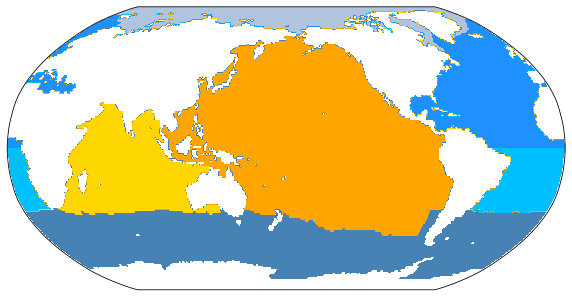

In [59]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl


# Define colors for different regions

#land, south, pac, indo, south atl, north atl, artc.
colors = ['white','steelblue', 'orange', 'gold', 'deepskyblue', 'dodgerblue' ,'lightsteelblue']

#alternatie colorbar
#colors = ['white','#A6C7F3','#172DBB',  '#1DAA24',  '#0D5F11', '#DEE5EE']

cmap = (mpl.colors.ListedColormap(colors)
       )
# Define projection (Robinson projection)
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 6))

# Plot data
im = ax.imshow(a, extent=[0, 360, -90, 90], transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=len(colors)-1)

# Add coastlines
#ax.coastlines()

"""# Add colorbar
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(colors)), orientation='vertical', shrink=0.5)
cbar.ax.set_yticklabels(labels[::-1])
"""
# Add title
#plt.title('Oceanic Regions')
plt.gca().invert_yaxis()
plt.show()